# 09 · Multimodal pipeline: register, transfer labels, train, fill the gaps

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** intermediate · 📊 **Data:** public Al–Cu single-depth map

The **whole correlative workflow** in one notebook, chaining notebooks **06**
(registration) and **03** (supervised learning): a mechanical map is aligned to a
second modality (a stand-in for EBSD), its labels are **transferred** onto the
indents, a model is **trained**, and it then **predicts everywhere, including
where the second modality could not measure**.

### 🎯 What you'll learn
1. Align a second modality to the mechanical map (recover a rigid transform).
2. **Transfer** its labels onto the measured indents.
3. **Train** a classifier on mechanics → transferred labels.
4. **Predict the full map**, filling the unmeasured gaps, with a confidence field.

### 🧭 What you need to know first
Notebooks **03** (random forests) and **06** (registration). Public Al–Cu data only.

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers ---
import os, sys, subprocess
def _find_src():
    for p in ("../src","src","mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p): return p
    return None
if _find_src() is None:
    subprocess.run(["git","clone","--depth","1",
        "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"], check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()

In [2]:
from scipy.ndimage import shift as nd_shift
from skimage.transform import rotate
from skimage.registration import phase_cross_correlation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
def z(a):
    m=np.isfinite(a); o=np.zeros_like(a,float); o[m]=(a[m]-a[m].mean())/a[m].std(); return o
def ncc(a,b): return float(np.mean(z(a)*z(b)))

## 1 · Mechanics (A) and a second modality (B): misaligned, with gaps
`A` is the hardness map. `B` is a second technique giving the true phase, but on a **shifted/rotated grid** with **unmeasured regions** (like un-indexed EBSD).

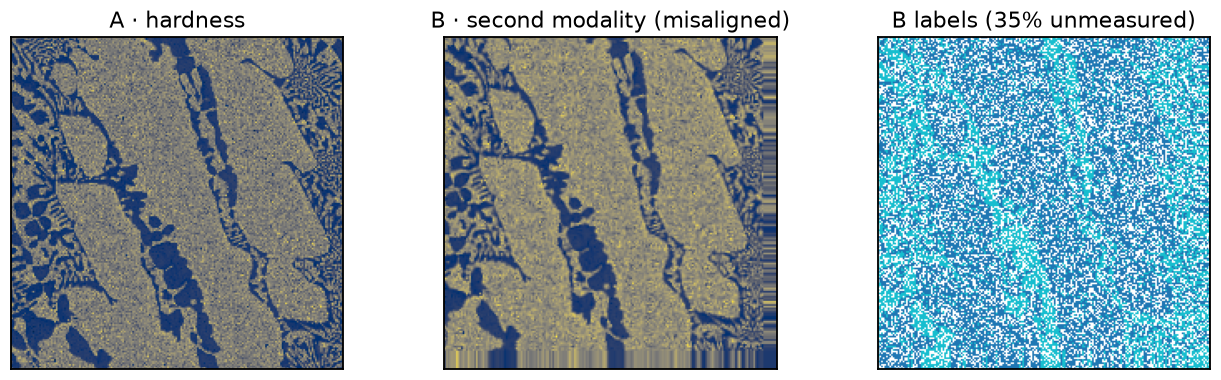

In [3]:
df = mm.load_map("alcu_2um")
A, ext = mm.map_to_grid(df, "H"); A = np.nan_to_num(A, nan=np.nanmean(A))
truth = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(df[["H","E"]])).astype(float)
df["phase"] = truth
GL, _ = mm.map_to_grid(df, "phase")
ang0, sh0 = 5.0, (10, -7)
Bimg = nd_shift(rotate(A, ang0, order=1, mode="reflect", preserve_range=True), sh0, mode="nearest")
Blab = nd_shift(rotate(GL, ang0, order=0, mode="reflect", preserve_range=True), sh0, order=0, mode="nearest")
rng = np.random.default_rng(0)
Blab[rng.random(Blab.shape) < 0.35] = np.nan
fig, ax = plt.subplots(1,3, figsize=(12,3.6))
for a,(im,t,c) in zip(ax,[(A,"A · hardness","cividis"),(Bimg,"B · second modality (misaligned)","cividis"),(Blab,"B labels (35% unmeasured)","tab10")]):
    a.imshow(im, origin="lower", cmap=c); a.set_title(t); a.set_xticks([]); a.set_yticks([])
fig.tight_layout()

## 2 · Register B to A
Recover the rotation + shift by maximising NCC (angle search + phase cross-correlation), then apply the same transform to the labels.

In [4]:
best=(-1,0.0,(0,0))
for ang in np.arange(-10,10.1,1.0):
    Br=rotate(Bimg,-ang,order=1,mode="reflect",preserve_range=True)
    s,_,_=phase_cross_correlation(A,Br,upsample_factor=10)
    v=ncc(A,nd_shift(Br,s,mode="nearest"))
    if v>best[0]: best=(v,ang,tuple(np.round(s,1)))
_,ang,sh=best
print(f"recovered angle={ang:.1f} deg (true {ang0}), shift={sh} (true {sh0}); NCC {best[0]:.2f}")
Blab_reg=nd_shift(rotate(Blab,-ang,order=0,mode="reflect",preserve_range=True,cval=np.nan), sh, order=0, mode="constant", cval=np.nan)

recovered angle=5.0 deg (true 5.0), shift=(np.float64(-9.3), np.float64(7.9)) (true (10, -7)); NCC 0.81


## 3 · Transfer the labels onto the indents
Each indent takes the aligned label of the pixel it sits on, where the second modality actually measured.

In [5]:
ys=np.sort(df["Y"].unique()); xs=np.sort(df["X"].unique())
yi=np.searchsorted(ys,df["Y"].values); xi=np.searchsorted(xs,df["X"].values)
lab=Blab_reg[np.clip(yi,0,Blab_reg.shape[0]-1), np.clip(xi,0,Blab_reg.shape[1]-1)]
have=np.isfinite(lab)
print(f"{have.sum():,} of {len(df):,} indents received a label ({100*have.mean():.0f}%); the rest are gaps to fill")

23,969 of 40,000 indents received a label (60%); the rest are gaps to fill


## 4 · Train on mechanics → transferred labels

In [6]:
X = df[["H","E","HE"]].values
Xtr,Xte,ytr,yte = train_test_split(X[have], lab[have].astype(int), test_size=0.3, random_state=0)
clf = RandomForestClassifier(200, random_state=0, n_jobs=-1).fit(Xtr, ytr)
print("held-out accuracy on transferred labels:", round(accuracy_score(yte, clf.predict(Xte)),3))

held-out accuracy on transferred labels: 0.842


## 5 · Predict everywhere: fill the gaps, with confidence

agreement with measured labels where they exist: 95.3%


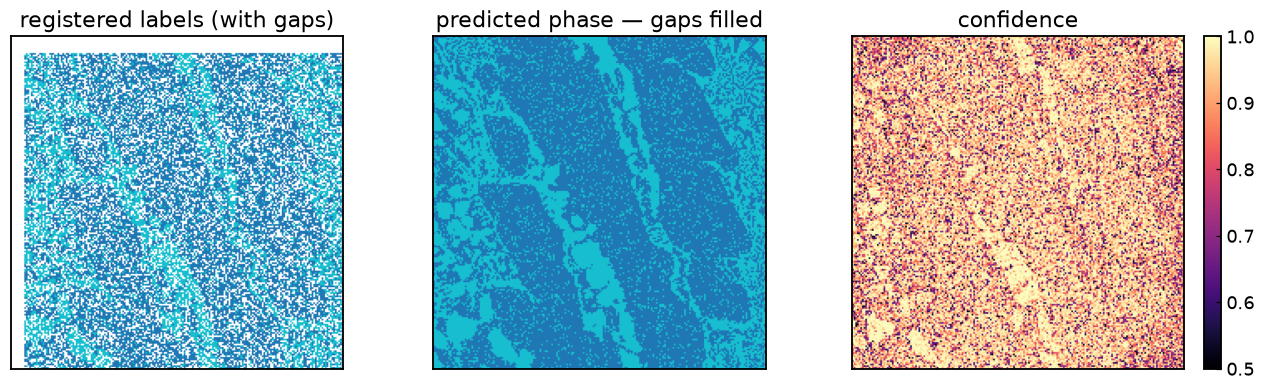

In [7]:
df["pred"]=clf.predict(X); df["conf"]=clf.predict_proba(X).max(1)
gp,_=mm.map_to_grid(df,"pred"); gc,_=mm.map_to_grid(df,"conf")
fig,ax=plt.subplots(1,3,figsize=(12,3.6))
ax[0].imshow(Blab_reg,origin="lower",cmap="tab10"); ax[0].set_title("registered labels (with gaps)")
ax[1].imshow(gp,origin="lower",cmap="tab10"); ax[1].set_title("predicted phase — gaps filled")
im=ax[2].imshow(gc,origin="lower",cmap="magma"); ax[2].set_title("confidence")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.colorbar(im,ax=ax[2],fraction=0.046); fig.tight_layout()
print(f"agreement with measured labels where they exist: {100*float((df['pred'].values[have]==lab[have].astype(int)).mean()):.1f}%")

### ✅ Self-check
A quick check that the pipeline behaved: registration recovered the rotation, and the classifier transfers labels well without memorising them. A bad edit trips the assert below.

In [8]:
# fails loudly if a key result drifts out of a sensible range (runs in CI too)
assert abs(ang - ang0) <= 2, "registration should recover the rotation to within 2 degrees"
acc = accuracy_score(yte, clf.predict(Xte))
assert 0.7 < acc < 1.0, "the classifier should transfer labels well, but not perfectly"
print(f"self-check passed: angle {ang:.0f} deg (true {ang0}), transfer accuracy {acc:.2f}")

self-check passed: angle 5 deg (true 5.0), transfer accuracy 0.84


## ✅ Recap
- The correlative pipeline: **register** → **transfer labels** → **train on
  mechanics** → **predict everywhere**, filling regions the second modality missed.
- The **confidence field** flags where to trust the filled labels, and where to
  measure more. This is the EBSD-informed correlative workflow, demonstrated on public Al–Cu data.

## 🔧 Try it yourself
1. Raise the hole fraction to 0.6. Does it still fill sensibly?
2. Swap the random forest for the curve CNN (notebook 04).
3. Report confidence *only* inside the filled gaps.

## 🩹 Common errors & fixes
- *Wrong recovered angle* → widen the angle search / raise `upsample_factor`.
- *Scrambled labels after transfer* → rotate/shift **label** images with `order=0`
  (nearest neighbour); never interpolate class indices.
- *Shape error after edits* → restart the kernel, run top-to-bottom.

---
**Next:** `14_uncertainty_quantification.ipynb` puts an honest error bar on predictions like these; `03a_evaluating_models.ipynb` is the trust-a-model prequel.